# Adaptive RAG

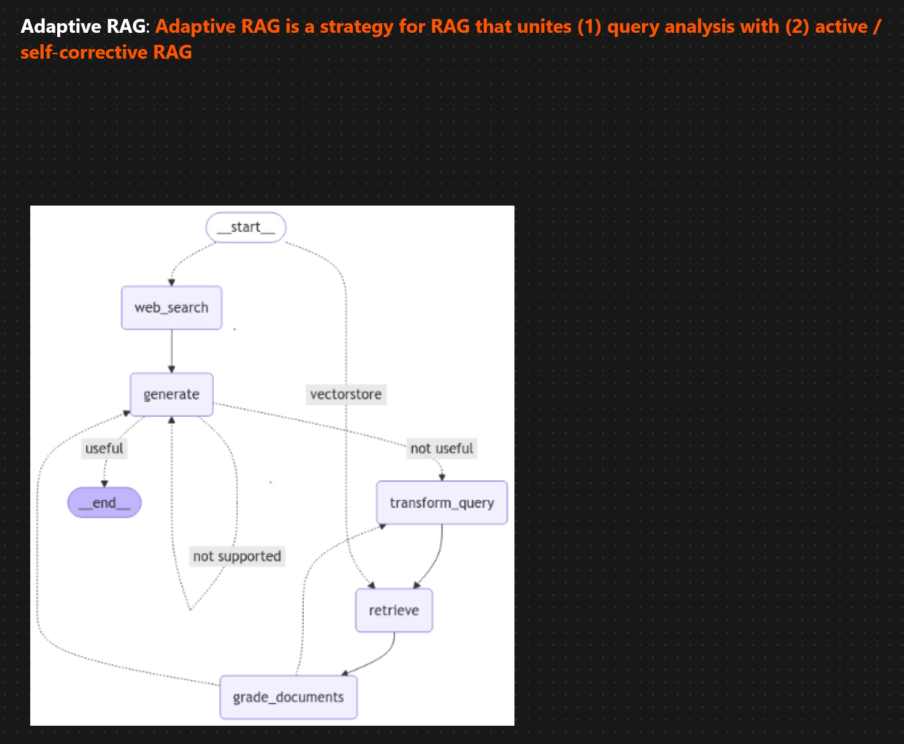

## Workflow

In [16]:
import os
from dotenv import load_dotenv
load_dotenv()  # loading all environment variables

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
os.environ["TAVILY_API_key"] = os.getenv("TAVILY_API_KEY")

In [17]:
# Search
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

In [18]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(urls).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
      chunk_size = 1000, chunk_overlap = 100
)

doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorDB
vectordb = FAISS.from_documents(
      documents = doc_splits,
      embedding = HuggingFaceEmbeddings(model_name = "all-MiniLM-L6-v2")
)

retriever = vectordb.as_retriever()

In [19]:
# Router
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

# Data Model
class RouteQuery(BaseModel):
      """ Route a user to most relevant datasource """
      datasource: Literal["vectorstore", "web_search"] = Field(
            description = "Given a user question choice to route it to web search or vectorstore."
      )

# LLm with function call
llm = ChatGroq(model="llama-3.3-70b-versatile")
structured_llm_router = llm.with_structured_output(RouteQuery)

# prompt
system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web-search."""

route_prompt = ChatPromptTemplate.from_messages(
      [
            ("system", system),
            ("human", "{question}")
      ]
)

question_router = route_prompt | structured_llm_router

print(question_router.invoke({"question": "What is a agent memory?"}))

datasource='vectorstore'


In [20]:
# Retrieval Grader

# Data Model
class GradeDocuments(BaseModel):
      "Binary Score for relevance of retrieved document"
      binary_score: str = Field (
            description="Documents are relevant to the question, 'yes' or 'no'"
      )

# llm with function call
llm = ChatGroq(model="llama-3.3-70b-versatile")
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# prompts
system = """You are a grader assessing relevance of a retrieved document to a user question. \n
      If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
      It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n 
      Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
      [
            ("system", system),
            ("human", "Retrieved Documents: \n\n {document} \n\n User Question: {question}")
      ]
)

retrieval_grader = grade_prompt | structured_llm_grader
question = "What is agent memory ?"
docs = retriever.invoke(question)
docs_text = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": docs_text}))

binary_score='yes'


In [21]:
# Generate
from langchain import hub
from langchain_core.output_parsers import StrOutputParser

# prompt
prompt = hub.pull("rlm/rag-prompt")

# llm
llm = ChatGroq(model="llama-3.3-70b-versatile")

# Post_processing
def format_docs(docs):
      return "\n\n".join(doc.page_content for doc in docs)

# chain
rag_chain = prompt | llm | StrOutputParser()

# Run 
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

Agent memory in a LLM-powered autonomous agent system refers to the capability to retain and recall information, which can be categorized into short-term memory and long-term memory. Short-term memory utilizes in-context learning to learn, while long-term memory leverages an external vector store and fast retrieval to retain information over extended periods. This allows the agent to learn from past experiences and make informed decisions.


In [22]:
# Halluciantion Grader

# Data Model
class GradeHallucination(BaseModel):
      """ Binary score for halluciantion present in the gerneration answer """
      binary_score: str = Field(
            description = "Answer is grounded in the facts, yes or no"
      )

llm = ChatGroq(model="llama-3.3-70b-versatile")
structured_llm_grader = llm.with_structured_output(GradeHallucination)

# prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n
      Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""

hallucination_prompt = ChatPromptTemplate(
      [
            ("system", system),
            ("human", "Set of facts: \n\n {documents} \n\n  LLM generation: {generation}")
      ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

GradeHallucination(binary_score='yes')

In [23]:
### Answer Grader


# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatGroq(model="llama-3.3-70b-versatile")
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='yes')

In [24]:
### Question Re-writer

# LLM
llm = ChatGroq(model="llama-3.3-70b-versatile")

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
     
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'To better optimize for vectorstore retrieval, I\'ll rephrase the question to make it more specific and informative. Here\'s an improved version:\n\n"What is the concept of agent memory in artificial intelligence, and how does it relate to an agent\'s ability to store and retrieve information?"\n\nAlternatively, a more concise version could be:\n\n"Agent memory in AI: definition, functions, and applications."\n\nThese revised questions aim to capture the underlying semantic intent of the original question by:\n\n1. Adding context: Specifying that the question is related to artificial intelligence.\n2. Clarifying the concept: Asking about the definition, functions, and applications of agent memory.\n3. Providing more keywords: Including terms like "artificial intelligence", "store", "retrieve", and "information" to help the vectorstore retrieval algorithm understand the topic better.'

In [25]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
      """
      Represents the state of our graph.
      Attributes: 
            question: question 
            generation: LLM generation 
            documents: List of documents
      """

      question: str
      generation: str
      documents: List[str]

In [26]:
from langchain.schema import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]

    # Web search
    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)

    return {"documents": web_results, "question": question}


### Edges ###


def route_question(state):
    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE QUESTION---")
    question = state["question"]
    source = question_router.invoke({"question": question})
    if source.datasource == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"


def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

In [27]:
from langgraph.graph import START, StateGraph, END

workflow = StateGraph(GraphState)

workflow.add_node("web_search", web_search)
workflow.add_node("retriever", retriever)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)

# Build graph
workflow.add_conditional_edges(
            START,
            route_question,
            {
                  "web_search": "web_search",
                  "vectorstore": "retriever"
            }
)     

workflow.add_edge("web_search", "generate")
workflow.add_edge("retriever", "grade_documents")
workflow.add_conditional_edges(
      "grade_documents",
      decide_to_generate,
      {
            "transform_query": "transform_query",
            "generate": "generate"
      }
)

workflow.add_edge("transform_query", "retriever")
workflow.add_conditional_edges(
      "generate",
      grade_generation_v_documents_and_question,
      {
            "not supported": "generate",
            "useful": END,
            "not useful": "transform_query"
      }
)

# Compile
app = workflow.compile()

In [28]:
from pprint import pprint

# Run
inputs = {
    "question": "What player at the Bears expected to draft first in the 2024 NFL draft?"
}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
"Node 'web_search':"
'\n---\n'
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---
"Node 'generate':"
'\n---\n'
('The player expected to be drafted first by the Bears in the 2024 NFL draft '
 'is quarterback Caleb Williams. The Bears have the first overall pick, and '
 'there is an expectation that they will select Williams with this pick.')


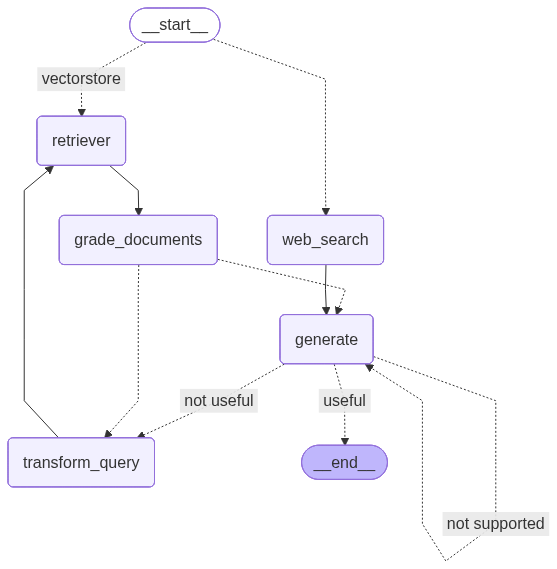

In [29]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass